# AI-Powered Fake News Detection Using Text Classification

### Machine Learning Internship Project

**Dataset:** WELFake Dataset

**Objective:**
Build a machine learning model that can classify a news article as Real or Fake using Natural Language Processing and Machine Learning algorithms.

## Step 1 : Import Required Libraries

In [2]:
# Libraries for working with data
import pandas as pd
import numpy as np

# Library for plotting graphs
import matplotlib.pyplot as plt

# Library for making graphs look better
import seaborn as sns

## Step 2 : Load the Dataset

In [4]:
# Loading the dataset

news_data = pd.read_csv("WELFake_Dataset.csv")

In [5]:
# Display the first five rows

news_data.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


## Step 3 : Understanding the Dataset

In [6]:
# Checking the number of rows and columns

news_data.shape

(72134, 4)

In [7]:
# Displaying the column names

news_data.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

## Step 4 : Checking missing values

In [8]:
# Checking missing values

news_data.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

## Step 5 : Checking Duplicate Records

In [9]:
# Checking duplicate rows in the dataset

news_data.duplicated().sum()

np.int64(0)

## Step 6 : Understanding / Analyze the Target Variable

In [10]:
# Checking how many news articles belong to each class

news_data["label"].value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

## Step 7 : Exploratory Data Analysis (EDA) (Visualize the Target Variable)

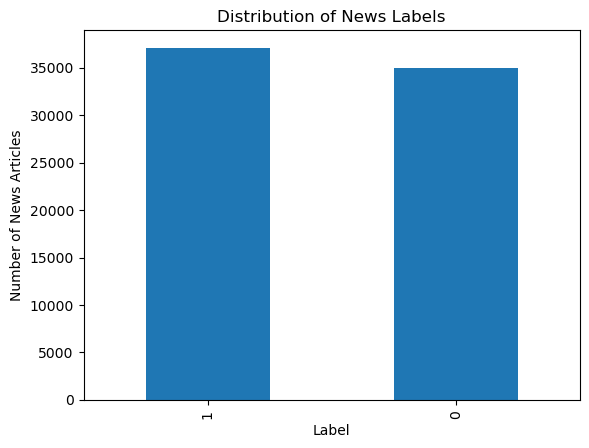

In [13]:
# Plot the distribution of Real and Fake news

news_data["label"].value_counts().plot(kind="bar")

plt.title("Distribution of News Labels")
plt.xlabel("Label")
plt.ylabel("Number of News Articles")

plt.show()

## Step 8 : Remove Unnecessary Columns

In [14]:
# Display all column names

news_data.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [15]:
# Remove the unnecessary column

news_data = news_data.drop("Unnamed: 0", axis=1)

In [16]:
# Display the remaining columns

news_data.columns

Index(['title', 'text', 'label'], dtype='object')

## Step 9 : Handle Missing Values

In [17]:
# Checking missing values

news_data.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [18]:
# Replacing missing values with empty strings

news_data = news_data.fillna("")

In [19]:
# Checking whether missing values are removed

news_data.isnull().sum()

title    0
text     0
label    0
dtype: int64

## Step 10 : Create the Input Feature

In [20]:
news_data.columns

Index(['title', 'text', 'label'], dtype='object')

In [21]:
# Combining title and text into one column

news_data["content"] = news_data["title"] + " " + news_data["text"]

In [22]:
news_data.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...


## Step 11 : Import NLP Libraries

In [23]:
# Libraries for text preprocessing

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

## Step 12 : Download NLTK Resources

In [24]:
# Downloading required NLTK files

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ashutosh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ashutosh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ashutosh\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ashutosh\AppData\Roaming\nltk_data...


True

## Step 12 : Text Preprocessing

In [25]:
# Creating an object for lemmatization

lemmatizer = WordNetLemmatizer()

# Loading English stopwords

stop_words = set(stopwords.words("english"))


# Function to clean the text

def clean_text(text):

    # Convert text into lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Split sentence into words
    words = word_tokenize(text)

    # Remove stopwords and lemmatize words
    cleaned_words = []

    for word in words:

        if word not in stop_words:
            word = lemmatizer.lemmatize(word)
            cleaned_words.append(word)

    # Join words back into one sentence
    cleaned_text = " ".join(cleaned_words)

    return cleaned_text

## Step 13 : Test the Text Cleaning Function

In [26]:
# Display the original news article

print("Original Text:\n")
print(news_data["content"][0])

Original Text:

LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of whi

In [28]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ashutosh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [29]:
# Display the cleaned news article
print("Cleaned Text:\n")
print(clean_text(news_data["content"][0]))

Cleaned Text:

law enforcement high alert following threat cop white blacklivesmatter fyf terrorist video comment expected barack obama member fyf fukyoflag blacklivesmatter movement called lynching hanging white people cop encouraged others radio show tuesday night turn tide kill white people cop send message killing black people america one f yoflag organizer called sunshine radio blog show hosted texas called sunshine f ing opinion radio show snapshot fyf lolatwhitefear twitter page p show urging supporter call fyf tonight continue dismantle illusion white snapshot twitter radio call invite fyf radio show aired p eastern standard time show caller clearly call lynching killing white people minute clip radio show heard provided breitbart texas someone would like referred hannibal already received death threat result interrupting fyf conference call unidentified black man said mother f kers start f ing like u bunch ni er takin one u roll said cause already roll gang anyway six seven bl

## Step 14 : Apply Text Preprocessing

In [30]:
# Applying the cleaning function to every news article

news_data["content"] = news_data["content"].apply(clean_text)

## STEP 15 : Verify the Cleaned Dataset

In [31]:
# Display the cleaned dataset

news_data.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert following threat co...
1,,Did they post their votes for Hillary already?,1,post vote hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general say charlo...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raised hindu us story christian c...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unvelis image terrifying new supe...


## STEP 16 : Check Dataset Information Again

In [32]:
# Display dataset information

news_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    72134 non-null  object
 1   text     72134 non-null  object
 2   label    72134 non-null  int64 
 3   content  72134 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.2+ MB


## Step 17 : Create Input and Output Variables

In [33]:
# Creating input and output variables

X = news_data["content"]

y = news_data["label"]

In [34]:
# Display the first five input samples

X.head()

0    law enforcement high alert following threat co...
1                            post vote hillary already
2    unbelievable obama attorney general say charlo...
3    bobby jindal raised hindu us story christian c...
4    satan russia unvelis image terrifying new supe...
Name: content, dtype: object

In [35]:
# Display the first five output labels

y.head()

0    1
1    1
2    1
3    0
4    1
Name: label, dtype: int64

## Step 18 : Train Test Split

In [36]:
# Importing train_test_split

from sklearn.model_selection import train_test_split

In [37]:
# Splitting the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
# Display the shape of training and testing data

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Data : (57707,)
Testing Data  : (14427,)

Training Labels : (57707,)
Testing Labels  : (14427,)


# Bag of Words Feature Extraction

## Step 19 : Feature Extraction using Bag of Words

In [39]:
# Importing CountVectorizer for Bag of Words

from sklearn.feature_extraction.text import CountVectorizer

In [40]:
# Creating the Bag of Words model

bow_vectorizer = CountVectorizer(max_features=5000)

In [41]:
# Learning the vocabulary from the training data

X_train_bow = bow_vectorizer.fit_transform(X_train)

In [42]:
# Converting the testing data using the same vocabulary

X_test_bow = bow_vectorizer.transform(X_test)

In [43]:
# Displaying the shape of Bag of Words features

print("Training Data Shape :", X_train_bow.shape)
print("Testing Data Shape  :", X_test_bow.shape)

Training Data Shape : (57707, 5000)
Testing Data Shape  : (14427, 5000)


## Step 20 : Logistic Regression using Bag of Words

In [44]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

In [45]:
# Creating the Logistic Regression model

logistic_model = LogisticRegression(max_iter=1000)

In [46]:
# Training the model

logistic_model.fit(X_train_bow, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
# Predicting the test data

y_pred = logistic_model.predict(X_test_bow)

In [48]:
# Importing evaluation metrics

from sklearn.metrics import accuracy_score

In [49]:
# Calculating accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9478061967144936


## Step 21 : Evaluate Logistic Regression Model

In [50]:
# Importing evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [51]:
# Calculating model performance

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9478061967144936
Precision: 0.9401901241087932
Recall   : 0.9595741813771729
F1 Score : 0.949783261087029


In [52]:
# Displaying the classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7006
           1       0.94      0.96      0.95      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427



In [53]:
# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6553  453]
 [ 300 7121]]


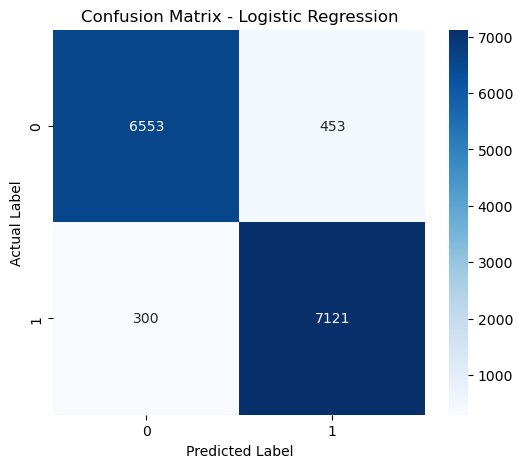

In [54]:
# Plotting the confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Step 22 : Store Model Results

In [55]:
# Dictionary to store model performance

results = {}

In [56]:
# Storing Logistic Regression results

results["Logistic Regression (BoW)"] = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

## Step 23 : K-Nearest Neighbors using Bag of Words

In [57]:
# Import KNN classifier

from sklearn.neighbors import KNeighborsClassifier

In [58]:
# Create the KNN model

knn_model = KNeighborsClassifier(n_neighbors=5)

In [59]:
# Train the KNN model

knn_model.fit(X_train_bow, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [60]:
# Predict the test data

knn_pred = knn_model.predict(X_test_bow)

In [61]:
# Calculate model accuracy

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.7864420877521314


## Step 24 : Evaluate K-Nearest Neighbors Model

In [62]:
# Calculate the evaluation metrics for KNN

knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

Accuracy : 0.7864420877521314
Precision: 0.7611940298507462
Recall   : 0.8521762565691955
F1 Score : 0.8041197787526225


In [63]:
# Display the classification report

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.82      0.72      0.77      7006
           1       0.76      0.85      0.80      7421

    accuracy                           0.79     14427
   macro avg       0.79      0.78      0.78     14427
weighted avg       0.79      0.79      0.79     14427



In [64]:
# Create the confusion matrix

knn_cm = confusion_matrix(y_test, knn_pred)

print(knn_cm)

[[5022 1984]
 [1097 6324]]


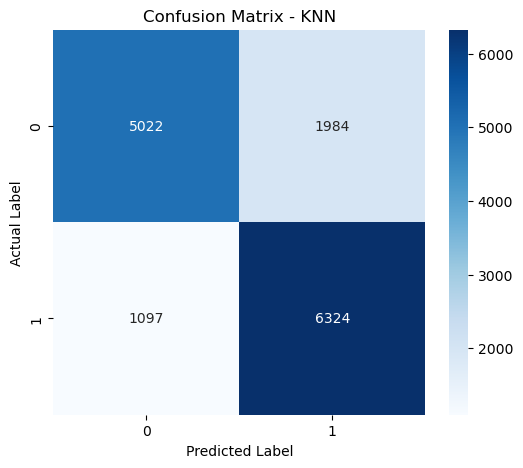

In [65]:
# Plot the confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [66]:
results["KNN (BoW)"] = {
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1 Score": knn_f1
}

In [67]:
results

{'Logistic Regression (BoW)': {'Accuracy': 0.9478061967144936,
  'Precision': 0.9401901241087932,
  'Recall': 0.9595741813771729,
  'F1 Score': 0.949783261087029},
 'KNN (BoW)': {'Accuracy': 0.7864420877521314,
  'Precision': 0.7611940298507462,
  'Recall': 0.8521762565691955,
  'F1 Score': 0.8041197787526225}}

## Step 25 : Random Forest using Bag of Words

In [68]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [69]:
# Creating the Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [70]:
# Training the Random Forest model

rf_model.fit(X_train_bow, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
# Predicting the test data

rf_pred = rf_model.predict(X_test_bow)

In [72]:
# Calculating accuracy

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9552228460525404


## Step 26 : Evaluate Random Forest

In [73]:
# Calculating evaluation metrics

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.9552228460525404
Precision: 0.9498074624883813
Recall   : 0.9638862686969412
F1 Score : 0.9567950775815944


In [74]:
# Displaying the classification report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      7006
           1       0.95      0.96      0.96      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.95      0.96     14427
weighted avg       0.96      0.96      0.96     14427



In [75]:
# Creating the confusion matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[6628  378]
 [ 268 7153]]


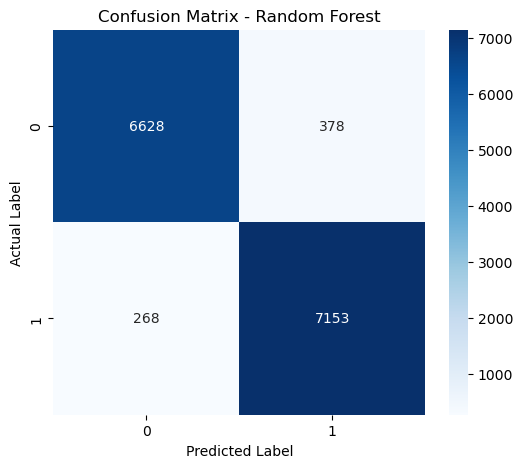

In [76]:
# Plotting the confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [78]:
# Storing Random Forest results

results["Random Forest (BoW)"] = {
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
}

In [79]:
results

{'Logistic Regression (BoW)': {'Accuracy': 0.9478061967144936,
  'Precision': 0.9401901241087932,
  'Recall': 0.9595741813771729,
  'F1 Score': 0.949783261087029},
 'KNN (BoW)': {'Accuracy': 0.7864420877521314,
  'Precision': 0.7611940298507462,
  'Recall': 0.8521762565691955,
  'F1 Score': 0.8041197787526225},
 'Random Forest (BoW)': {'Accuracy': 0.9552228460525404,
  'Precision': 0.9498074624883813,
  'Recall': 0.9638862686969412,
  'F1 Score': 0.9567950775815944}}

## Step 27 : Neural Network using Bag of Words

In [80]:
# Import Neural Network

from sklearn.neural_network import MLPClassifier

In [81]:
# Creating the Neural Network model

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

In [82]:
# Training the Neural Network

mlp_model.fit(X_train_bow, y_train)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [83]:
# Predicting the test data

mlp_pred = mlp_model.predict(X_test_bow)

In [84]:
# Calculating accuracy

mlp_accuracy = accuracy_score(y_test, mlp_pred)

print("Neural Network Accuracy :", mlp_accuracy)

Neural Network Accuracy : 0.9646496153046371


## Step 28 : Evaluate Neural Network Model

In [85]:
# Calculating evaluation metrics

mlp_precision = precision_score(y_test, mlp_pred)
mlp_recall = recall_score(y_test, mlp_pred)
mlp_f1 = f1_score(y_test, mlp_pred)

print("Accuracy :", mlp_accuracy)
print("Precision:", mlp_precision)
print("Recall   :", mlp_recall)
print("F1 Score :", mlp_f1)

Accuracy : 0.9646496153046371
Precision: 0.9589586930535263
Recall   : 0.9729147015227059
F1 Score : 0.9658862876254181


In [86]:
# Displaying classification report

print(classification_report(y_test, mlp_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      7006
           1       0.96      0.97      0.97      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.96      0.96     14427
weighted avg       0.96      0.96      0.96     14427



In [87]:
# Creating confusion matrix

mlp_cm = confusion_matrix(y_test, mlp_pred)

print(mlp_cm)

[[6697  309]
 [ 201 7220]]


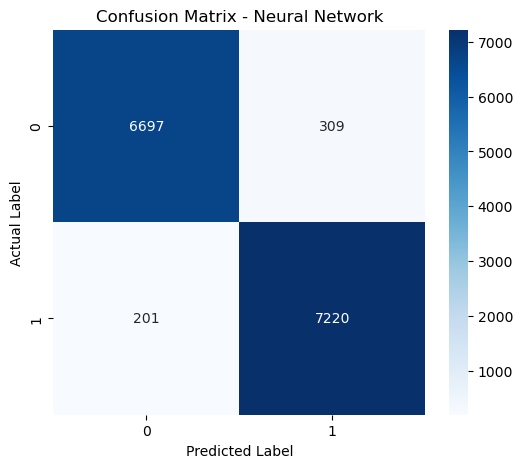

In [88]:
# Plotting confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    mlp_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [89]:
# Storing Neural Network results

results["Neural Network (BoW)"] = {
    "Accuracy": mlp_accuracy,
    "Precision": mlp_precision,
    "Recall": mlp_recall,
    "F1 Score": mlp_f1
}

In [90]:
results

{'Logistic Regression (BoW)': {'Accuracy': 0.9478061967144936,
  'Precision': 0.9401901241087932,
  'Recall': 0.9595741813771729,
  'F1 Score': 0.949783261087029},
 'KNN (BoW)': {'Accuracy': 0.7864420877521314,
  'Precision': 0.7611940298507462,
  'Recall': 0.8521762565691955,
  'F1 Score': 0.8041197787526225},
 'Random Forest (BoW)': {'Accuracy': 0.9552228460525404,
  'Precision': 0.9498074624883813,
  'Recall': 0.9638862686969412,
  'F1 Score': 0.9567950775815944},
 'Neural Network (BoW)': {'Accuracy': 0.9646496153046371,
  'Precision': 0.9589586930535263,
  'Recall': 0.9729147015227059,
  'F1 Score': 0.9658862876254181}}

## Step 29 : Comparison of Bag of Words Models

In [91]:
# Creating comparison table

bow_results = pd.DataFrame(results).T

bow_results

,Accuracy,Precision,Recall,F1 Score
Logistic Regression (BoW),0.947806,0.940190,0.959574,0.949783
KNN (BoW),0.786442,0.761194,0.852176,0.804120
Random Forest (BoW),0.955223,0.949807,0.963886,0.956795
Neural Network (BoW),0.964650,0.958959,0.972915,0.965886


In [92]:
# Finding the best model

best_bow_model = bow_results["Accuracy"].idxmax()

print("Best Bag of Words Model :", best_bow_model)

Best Bag of Words Model : Neural Network (BoW)


# TF-IDF Feature Extraction

## Step 31 : TF-IDF Vectorization

In [94]:
# Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

In [95]:
# Creating TF-IDF Vectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

In [96]:
# Learn vocabulary from training data

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

In [97]:
# Transform testing data

X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [98]:
print("Training Data Shape :", X_train_tfidf.shape)
print("Testing Data Shape :", X_test_tfidf.shape)

Training Data Shape : (57707, 5000)
Testing Data Shape : (14427, 5000)


## Step 32 : Logistic Regression using TF-IDF

In [99]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

In [100]:
# Creating the Logistic Regression model

tfidf_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [101]:
# Training the Logistic Regression model

tfidf_lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [102]:
# Predicting the test data

tfidf_lr_pred = tfidf_lr_model.predict(X_test_tfidf)

In [103]:
# Calculating model accuracy

tfidf_lr_accuracy = accuracy_score(
    y_test,
    tfidf_lr_pred
)

print("TF-IDF Logistic Regression Accuracy :", tfidf_lr_accuracy)

TF-IDF Logistic Regression Accuracy : 0.9477368822346989


In [104]:
# Calculating evaluation metrics

tfidf_lr_precision = precision_score(y_test, tfidf_lr_pred)
tfidf_lr_recall = recall_score(y_test, tfidf_lr_pred)
tfidf_lr_f1 = f1_score(y_test, tfidf_lr_pred)

print("Accuracy :", tfidf_lr_accuracy)
print("Precision:", tfidf_lr_precision)
print("Recall   :", tfidf_lr_recall)
print("F1 Score :", tfidf_lr_f1)

Accuracy : 0.9477368822346989
Precision: 0.9464309629034419
Recall   : 0.952297534025064
F1 Score : 0.949355185384202


In [105]:
print(classification_report(y_test, tfidf_lr_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7006
           1       0.95      0.95      0.95      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427



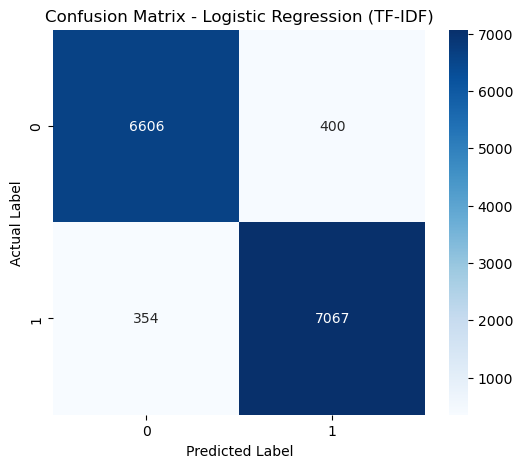

In [106]:
tfidf_lr_cm = confusion_matrix(y_test, tfidf_lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    tfidf_lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression (TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [107]:
# Dictionary to store TF-IDF model results

tfidf_results = {}

In [108]:
tfidf_results["Logistic Regression (TF-IDF)"] = {
    "Accuracy": tfidf_lr_accuracy,
    "Precision": tfidf_lr_precision,
    "Recall": tfidf_lr_recall,
    "F1 Score": tfidf_lr_f1
}

In [110]:
tfidf_results

{'Logistic Regression (TF-IDF)': {'Accuracy': 0.9477368822346989,
  'Precision': 0.9464309629034419,
  'Recall': 0.952297534025064,
  'F1 Score': 0.949355185384202}}

## Step 33 : K-Nearest Neighbors using TF-IDF

In [111]:
# Import KNN classifier

from sklearn.neighbors import KNeighborsClassifier

In [112]:
# Creating the KNN model

tfidf_knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [113]:
# Training the KNN model

tfidf_knn_model.fit(
    X_train_tfidf,
    y_train
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [114]:
# Predicting the test data

tfidf_knn_pred = tfidf_knn_model.predict(
    X_test_tfidf
)

In [115]:
# Calculating model accuracy

tfidf_knn_accuracy = accuracy_score(
    y_test,
    tfidf_knn_pred
)

print("TF-IDF KNN Accuracy :", tfidf_knn_accuracy)

TF-IDF KNN Accuracy : 0.7099882165384349


In [116]:
# Calculating evaluation metrics

tfidf_knn_precision = precision_score(
    y_test,
    tfidf_knn_pred
)

tfidf_knn_recall = recall_score(
    y_test,
    tfidf_knn_pred
)

tfidf_knn_f1 = f1_score(
    y_test,
    tfidf_knn_pred
)

print("Accuracy :", tfidf_knn_accuracy)
print("Precision:", tfidf_knn_precision)
print("Recall   :", tfidf_knn_recall)
print("F1 Score :", tfidf_knn_f1)

Accuracy : 0.7099882165384349
Precision: 0.6511063392773784
Recall   : 0.9397655302519876
F1 Score : 0.7692477388043238


In [117]:
# Classification report

print(classification_report(
    y_test,
    tfidf_knn_pred
))

              precision    recall  f1-score   support

           0       0.88      0.47      0.61      7006
           1       0.65      0.94      0.77      7421

    accuracy                           0.71     14427
   macro avg       0.77      0.70      0.69     14427
weighted avg       0.76      0.71      0.69     14427



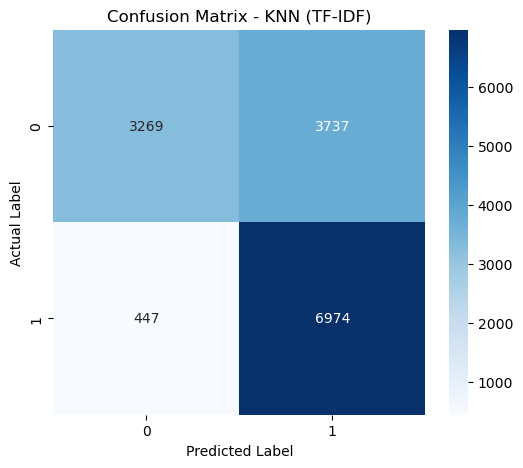

In [118]:
# Confusion matrix

tfidf_knn_cm = confusion_matrix(
    y_test,
    tfidf_knn_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    tfidf_knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - KNN (TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [119]:
# Store KNN results

tfidf_results["KNN (TF-IDF)"] = {
    "Accuracy": tfidf_knn_accuracy,
    "Precision": tfidf_knn_precision,
    "Recall": tfidf_knn_recall,
    "F1 Score": tfidf_knn_f1
}

In [120]:
tfidf_results

{'Logistic Regression (TF-IDF)': {'Accuracy': 0.9477368822346989,
  'Precision': 0.9464309629034419,
  'Recall': 0.952297534025064,
  'F1 Score': 0.949355185384202},
 'KNN (TF-IDF)': {'Accuracy': 0.7099882165384349,
  'Precision': 0.6511063392773784,
  'Recall': 0.9397655302519876,
  'F1 Score': 0.7692477388043238}}

## Step 34 : Random Forest using TF-IDF

In [121]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [122]:
# Creating the Random Forest model

tfidf_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [123]:
# Training the model

tfidf_rf_model.fit(
    X_train_tfidf,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:
# Predicting the test data

tfidf_rf_pred = tfidf_rf_model.predict(
    X_test_tfidf
)

In [125]:
# Calculating accuracy

tfidf_rf_accuracy = accuracy_score(
    y_test,
    tfidf_rf_pred
)

print("TF-IDF Random Forest Accuracy :", tfidf_rf_accuracy)

TF-IDF Random Forest Accuracy : 0.9551535315727455


In [126]:
# Calculating evaluation metrics

tfidf_rf_precision = precision_score(
    y_test,
    tfidf_rf_pred
)

tfidf_rf_recall = recall_score(
    y_test,
    tfidf_rf_pred
)

tfidf_rf_f1 = f1_score(
    y_test,
    tfidf_rf_pred
)

print("Accuracy :", tfidf_rf_accuracy)
print("Precision:", tfidf_rf_precision)
print("Recall   :", tfidf_rf_recall)
print("F1 Score :", tfidf_rf_f1)

Accuracy : 0.9551535315727455
Precision: 0.9455406471981057
Recall   : 0.9686026142029376
F1 Score : 0.9569327031884444


In [127]:
print(classification_report(
    y_test,
    tfidf_rf_pred
))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      7006
           1       0.95      0.97      0.96      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.95      0.96     14427
weighted avg       0.96      0.96      0.96     14427



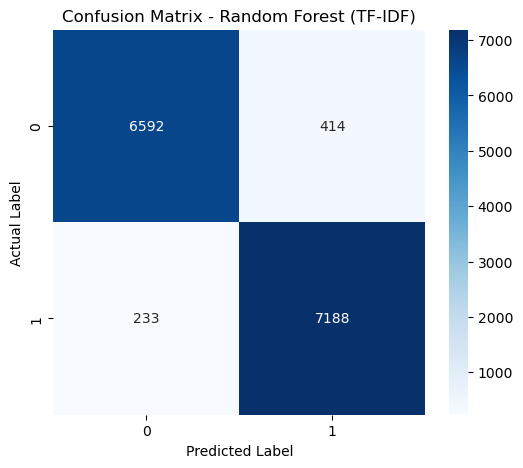

In [128]:
tfidf_rf_cm = confusion_matrix(
    y_test,
    tfidf_rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    tfidf_rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest (TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [129]:
tfidf_results["Random Forest (TF-IDF)"] = {
    "Accuracy": tfidf_rf_accuracy,
    "Precision": tfidf_rf_precision,
    "Recall": tfidf_rf_recall,
    "F1 Score": tfidf_rf_f1
}

In [130]:
tfidf_results

{'Logistic Regression (TF-IDF)': {'Accuracy': 0.9477368822346989,
  'Precision': 0.9464309629034419,
  'Recall': 0.952297534025064,
  'F1 Score': 0.949355185384202},
 'KNN (TF-IDF)': {'Accuracy': 0.7099882165384349,
  'Precision': 0.6511063392773784,
  'Recall': 0.9397655302519876,
  'F1 Score': 0.7692477388043238},
 'Random Forest (TF-IDF)': {'Accuracy': 0.9551535315727455,
  'Precision': 0.9455406471981057,
  'Recall': 0.9686026142029376,
  'F1 Score': 0.9569327031884444}}

## Step 35 : Neural Network using TF-IDF

In [131]:
# Import Neural Network

from sklearn.neural_network import MLPClassifier

In [132]:
# Creating the Neural Network model

tfidf_mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

In [138]:
# Training the Neural Network

tfidf_mlp_model.fit(
    X_train_tfidf,
    y_train
)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [139]:
# Predicting the test data

tfidf_mlp_pred = tfidf_mlp_model.predict(
    X_test_tfidf
)

In [140]:
# Calculating accuracy

tfidf_mlp_accuracy = accuracy_score(
    y_test,
    tfidf_mlp_pred
)

print("TF-IDF Neural Network Accuracy :", tfidf_mlp_accuracy)

TF-IDF Neural Network Accuracy : 0.9584113121231025


In [141]:
# Calculating evaluation metrics

tfidf_mlp_precision = precision_score(
    y_test,
    tfidf_mlp_pred
)

tfidf_mlp_recall = recall_score(
    y_test,
    tfidf_mlp_pred
)

tfidf_mlp_f1 = f1_score(
    y_test,
    tfidf_mlp_pred
)

print("Accuracy :", tfidf_mlp_accuracy)
print("Precision:", tfidf_mlp_precision)
print("Recall   :", tfidf_mlp_recall)
print("F1 Score :", tfidf_mlp_f1)

Accuracy : 0.9584113121231025
Precision: 0.9549152994531146
Recall   : 0.9646947850693977
F1 Score : 0.9597801313849041


In [142]:
print(classification_report(
    y_test,
    tfidf_mlp_pred
))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7006
           1       0.95      0.96      0.96      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.96      0.96     14427
weighted avg       0.96      0.96      0.96     14427



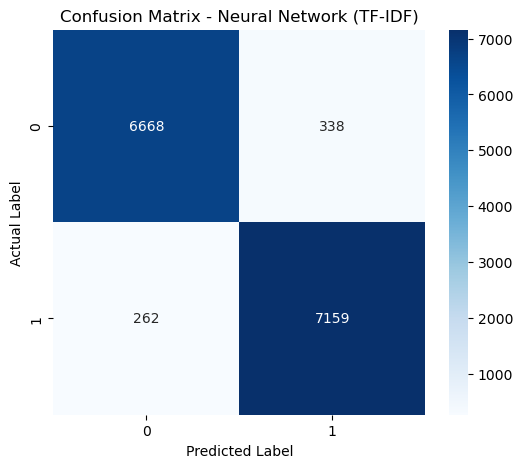

In [143]:
tfidf_mlp_cm = confusion_matrix(
    y_test,
    tfidf_mlp_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    tfidf_mlp_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Neural Network (TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [144]:
tfidf_results["Neural Network (TF-IDF)"] = {
    "Accuracy": tfidf_mlp_accuracy,
    "Precision": tfidf_mlp_precision,
    "Recall": tfidf_mlp_recall,
    "F1 Score": tfidf_mlp_f1
}

In [145]:
tfidf_results

{'Logistic Regression (TF-IDF)': {'Accuracy': 0.9477368822346989,
  'Precision': 0.9464309629034419,
  'Recall': 0.952297534025064,
  'F1 Score': 0.949355185384202},
 'KNN (TF-IDF)': {'Accuracy': 0.7099882165384349,
  'Precision': 0.6511063392773784,
  'Recall': 0.9397655302519876,
  'F1 Score': 0.7692477388043238},
 'Random Forest (TF-IDF)': {'Accuracy': 0.9551535315727455,
  'Precision': 0.9455406471981057,
  'Recall': 0.9686026142029376,
  'F1 Score': 0.9569327031884444},
 'Neural Network (TF-IDF)': {'Accuracy': 0.9584113121231025,
  'Precision': 0.9549152994531146,
  'Recall': 0.9646947850693977,
  'F1 Score': 0.9597801313849041}}

In [146]:
tfidf_table = pd.DataFrame(tfidf_results).T

tfidf_table

,Accuracy,Precision,Recall,F1 Score
Logistic Regression (TF-IDF),0.947737,0.946431,0.952298,0.949355
KNN (TF-IDF),0.709988,0.651106,0.939766,0.769248
Random Forest (TF-IDF),0.955154,0.945541,0.968603,0.956933
Neural Network (TF-IDF),0.958411,0.954915,0.964695,0.959780


In [147]:
best_tfidf_model = tfidf_table["Accuracy"].idxmax()

print("Best TF-IDF Model :", best_tfidf_model)

Best TF-IDF Model : Neural Network (TF-IDF)


#  Sentence Embeddings

## Step 36 : Import Sentence Transformer Libraries

In [16]:
# Install Sentence Transformers

!pip install sentence-transformers

Defaulting to user installation because normal site-packages is not writeable
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/596.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/596.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/596.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/596.4 kB ? eta -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [17]:
# Import required libraries

import numpy as np

from sentence_transformers import SentenceTransformer

In [18]:
# Load the pre-trained Sentence Transformer model

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Sentence Transformer model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Ashutosh\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ashutosh\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence Transformer model loaded successfully!


In [20]:
# Generate sentence embeddings

X_embeddings = embedding_model.encode(
    news_data["content"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/2255 [00:00<?, ?it/s]

## Step 39 : Verify Sentence Embeddings

In [21]:
# Shape of embeddings

print(X_embeddings.shape)

(72134, 384)


In [22]:
# Display the first embedding

print(X_embeddings[0])

[-4.13799509e-02 -8.27666596e-02 -4.86410260e-02  1.95945371e-02
  3.91946211e-02  8.23654234e-02  6.11352623e-02 -4.05954272e-02
 -3.40996906e-02  3.02644800e-02  1.23772928e-02 -6.77457526e-02
  6.67248517e-02 -6.95978552e-02 -8.11667740e-02  3.65421660e-02
  9.47774798e-02 -2.69935913e-02 -1.41359285e-01  1.30398013e-02
  2.60231923e-02  2.10053567e-02 -7.33507611e-03  1.74564356e-03
 -9.39539671e-02  4.05763276e-02 -7.84433261e-02 -2.45878892e-03
 -6.38943315e-02 -1.13481693e-02  8.36269110e-02  2.24270765e-02
  5.80104478e-02  7.55914077e-02 -1.97029561e-02 -7.47487471e-02
  1.01858452e-01  7.29610994e-02  3.43346484e-02  2.21083965e-02
 -2.56333016e-02 -4.09827791e-02  4.30837907e-02  2.72299927e-02
 -4.21598852e-02 -5.19432388e-02 -2.29985956e-02  4.30527987e-04
  4.37874421e-02 -5.93705140e-02  1.78256854e-02 -1.05265724e-02
  1.57682281e-02  6.90630153e-02 -2.92190872e-02 -5.65226115e-02
 -4.01077569e-02  1.21530890e-02  3.47518660e-02  9.84920375e-03
 -8.08136165e-02  4.62780

## Step 40 : Create Input and Output Variables

In [23]:
# Creating input and output variables

X = X_embeddings

y = news_data["label"]

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

Input Shape : (72134, 384)
Output Shape: (72134,)


## Step 41 : Split the Dataset

In [24]:
# Import train_test_split

from sklearn.model_selection import train_test_split

In [25]:
# Split the dataset into training and testing sets

X_train_embed, X_test_embed, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
print("Training Shape :", X_train_embed.shape)
print("Testing Shape  :", X_test_embed.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Shape : (57707, 384)
Testing Shape  : (14427, 384)

Training Labels : (57707,)
Testing Labels  : (14427,)


## Step 42 : Logistic Regression using Sentence Embeddings

In [27]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

In [28]:
# Create Logistic Regression model

embed_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [29]:
# Train the model

embed_lr_model.fit(
    X_train_embed,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
# Predict the testing data

embed_lr_pred = embed_lr_model.predict(
    X_test_embed
)

In [31]:
# Calculate accuracy

from sklearn.metrics import accuracy_score

embed_lr_accuracy = accuracy_score(
    y_test,
    embed_lr_pred
)

print("Sentence Embedding Logistic Regression Accuracy :", embed_lr_accuracy)

Sentence Embedding Logistic Regression Accuracy : 0.8522215290774243


## Step 43 : Evaluate Logistic Regression (Sentence Embeddings)

In [32]:
# Import evaluation metrics

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Calculate evaluation metrics

embed_lr_precision = precision_score(y_test, embed_lr_pred)

embed_lr_recall = recall_score(y_test, embed_lr_pred)

embed_lr_f1 = f1_score(y_test, embed_lr_pred)

print("Accuracy :", embed_lr_accuracy)
print("Precision:", embed_lr_precision)
print("Recall   :", embed_lr_recall)
print("F1 Score :", embed_lr_f1)

Accuracy : 0.8522215290774243
Precision: 0.856353591160221
Recall   : 0.856353591160221
F1 Score : 0.856353591160221


In [33]:
# Display classification report

print(classification_report(
    y_test,
    embed_lr_pred
))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      7006
           1       0.86      0.86      0.86      7421

    accuracy                           0.85     14427
   macro avg       0.85      0.85      0.85     14427
weighted avg       0.85      0.85      0.85     14427



In [34]:
# Create confusion matrix

embed_lr_cm = confusion_matrix(
    y_test,
    embed_lr_pred
)

print(embed_lr_cm)

[[5940 1066]
 [1066 6355]]


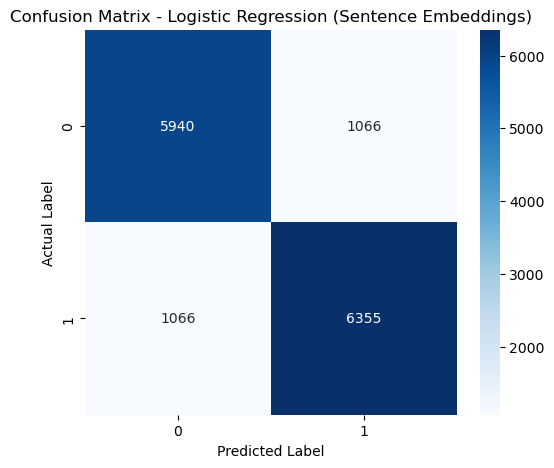

In [35]:
# Plot confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    embed_lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression (Sentence Embeddings)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [36]:
# Dictionary to store Sentence Embedding model results

embedding_results = {}

In [37]:
embedding_results["Logistic Regression (Sentence Embedding)"] = {
    "Accuracy": embed_lr_accuracy,
    "Precision": embed_lr_precision,
    "Recall": embed_lr_recall,
    "F1 Score": embed_lr_f1
}

In [38]:
embedding_results

{'Logistic Regression (Sentence Embedding)': {'Accuracy': 0.8522215290774243,
  'Precision': 0.856353591160221,
  'Recall': 0.856353591160221,
  'F1 Score': 0.856353591160221}}

## Step 44 : K-Nearest Neighbors using Sentence Embeddings

In [39]:
# Import KNN

from sklearn.neighbors import KNeighborsClassifier

In [40]:
# Create KNN model

embed_knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [41]:
# Train the model

embed_knn_model.fit(
    X_train_embed,
    y_train
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
# Predict testing data

embed_knn_pred = embed_knn_model.predict(
    X_test_embed
)

In [43]:
# Calculate accuracy

embed_knn_accuracy = accuracy_score(
    y_test,
    embed_knn_pred
)

print("Sentence Embedding KNN Accuracy :", embed_knn_accuracy)

Sentence Embedding KNN Accuracy : 0.8457752824565051


## Step 45 : Evaluate KNN (Sentence Embeddings)

In [44]:
# Calculate evaluation metrics

embed_knn_precision = precision_score(
    y_test,
    embed_knn_pred
)

embed_knn_recall = recall_score(
    y_test,
    embed_knn_pred
)

embed_knn_f1 = f1_score(
    y_test,
    embed_knn_pred
)

print("Accuracy :", embed_knn_accuracy)
print("Precision:", embed_knn_precision)
print("Recall   :", embed_knn_recall)
print("F1 Score :", embed_knn_f1)

Accuracy : 0.8457752824565051
Precision: 0.8604328523862376
Recall   : 0.8357364236625792
F1 Score : 0.847904846537699


In [45]:
# Classification report

print(classification_report(
    y_test,
    embed_knn_pred
))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      7006
           1       0.86      0.84      0.85      7421

    accuracy                           0.85     14427
   macro avg       0.85      0.85      0.85     14427
weighted avg       0.85      0.85      0.85     14427



In [46]:
# Confusion Matrix

embed_knn_cm = confusion_matrix(
    y_test,
    embed_knn_pred
)

print(embed_knn_cm)

[[6000 1006]
 [1219 6202]]


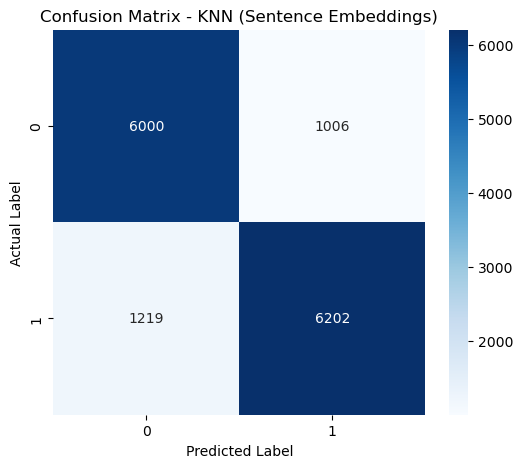

In [47]:
# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    embed_knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - KNN (Sentence Embeddings)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [48]:
# Store results

embedding_results["KNN (Sentence Embedding)"] = {
    "Accuracy": embed_knn_accuracy,
    "Precision": embed_knn_precision,
    "Recall": embed_knn_recall,
    "F1 Score": embed_knn_f1
}

In [49]:
embedding_results

{'Logistic Regression (Sentence Embedding)': {'Accuracy': 0.8522215290774243,
  'Precision': 0.856353591160221,
  'Recall': 0.856353591160221,
  'F1 Score': 0.856353591160221},
 'KNN (Sentence Embedding)': {'Accuracy': 0.8457752824565051,
  'Precision': 0.8604328523862376,
  'Recall': 0.8357364236625792,
  'F1 Score': 0.847904846537699}}

## Step 46 : Random Forest using Sentence Embeddings

In [50]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [51]:
# Create Random Forest model

embed_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [52]:
# Train the model

embed_rf_model.fit(
    X_train_embed,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
# Predict testing data

embed_rf_pred = embed_rf_model.predict(
    X_test_embed
)

In [54]:
# Calculate accuracy

embed_rf_accuracy = accuracy_score(
    y_test,
    embed_rf_pred
)

print("Sentence Embedding Random Forest Accuracy :", embed_rf_accuracy)

Sentence Embedding Random Forest Accuracy : 0.8619948707284952


## Step 47 : Evaluate Random Forest (Sentence Embeddings)

In [55]:
# Calculate evaluation metrics

embed_rf_precision = precision_score(
    y_test,
    embed_rf_pred
)

embed_rf_recall = recall_score(
    y_test,
    embed_rf_pred
)

embed_rf_f1 = f1_score(
    y_test,
    embed_rf_pred
)

print("Accuracy :", embed_rf_accuracy)
print("Precision:", embed_rf_precision)
print("Recall   :", embed_rf_recall)
print("F1 Score :", embed_rf_f1)

Accuracy : 0.8619948707284952
Precision: 0.8630649906392084
Recall   : 0.8696941113057539
F1 Score : 0.866366870259749


In [56]:
# Display classification report

print(classification_report(
    y_test,
    embed_rf_pred
))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      7006
           1       0.86      0.87      0.87      7421

    accuracy                           0.86     14427
   macro avg       0.86      0.86      0.86     14427
weighted avg       0.86      0.86      0.86     14427



In [57]:
# Create confusion matrix

embed_rf_cm = confusion_matrix(
    y_test,
    embed_rf_pred
)

print(embed_rf_cm)

[[5982 1024]
 [ 967 6454]]


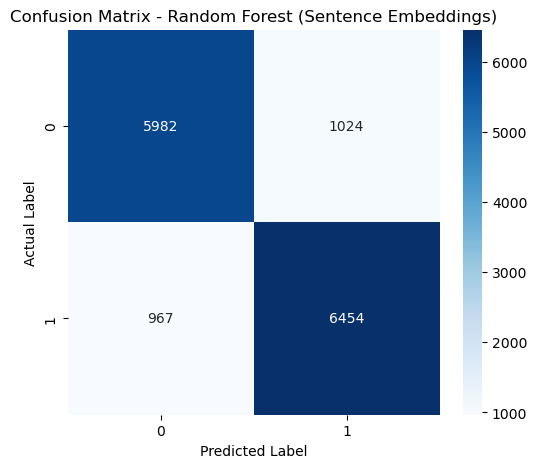

In [58]:
# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    embed_rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest (Sentence Embeddings)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [59]:
# Store Random Forest results

embedding_results["Random Forest (Sentence Embedding)"] = {
    "Accuracy": embed_rf_accuracy,
    "Precision": embed_rf_precision,
    "Recall": embed_rf_recall,
    "F1 Score": embed_rf_f1
}

In [60]:
embedding_results

{'Logistic Regression (Sentence Embedding)': {'Accuracy': 0.8522215290774243,
  'Precision': 0.856353591160221,
  'Recall': 0.856353591160221,
  'F1 Score': 0.856353591160221},
 'KNN (Sentence Embedding)': {'Accuracy': 0.8457752824565051,
  'Precision': 0.8604328523862376,
  'Recall': 0.8357364236625792,
  'F1 Score': 0.847904846537699},
 'Random Forest (Sentence Embedding)': {'Accuracy': 0.8619948707284952,
  'Precision': 0.8630649906392084,
  'Recall': 0.8696941113057539,
  'F1 Score': 0.866366870259749}}

## Step 48 : Neural Network using Sentence Embeddings

In [61]:
# Import Neural Network

from sklearn.neural_network import MLPClassifier

In [62]:
# Create Neural Network model

embed_mlp_model = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=100,
    early_stopping=True,
    random_state=42
)

In [63]:
# Train the model

embed_mlp_model.fit(
    X_train_embed,
    y_train
)

,hidden_layer_sizes,"(50,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,100
,shuffle,True
,random_state,42


In [64]:
# Predict testing data

embed_mlp_pred = embed_mlp_model.predict(
    X_test_embed
)

In [65]:
# Calculate accuracy

embed_mlp_accuracy = accuracy_score(
    y_test,
    embed_mlp_pred
)

print("Sentence Embedding Neural Network Accuracy :", embed_mlp_accuracy)

Sentence Embedding Neural Network Accuracy : 0.897345255423858


## Step 49 : Evaluate Neural Network (Sentence Embeddings)

In [66]:
# Calculate evaluation metrics

embed_mlp_precision = precision_score(
    y_test,
    embed_mlp_pred
)

embed_mlp_recall = recall_score(
    y_test,
    embed_mlp_pred
)

embed_mlp_f1 = f1_score(
    y_test,
    embed_mlp_pred
)

print("Accuracy :", embed_mlp_accuracy)
print("Precision:", embed_mlp_precision)
print("Recall   :", embed_mlp_recall)
print("F1 Score :", embed_mlp_f1)

Accuracy : 0.897345255423858
Precision: 0.8955780500799148
Recall   : 0.9060773480662984
F1 Score : 0.9007971063031683


In [67]:
# Classification Report

print(classification_report(
    y_test,
    embed_mlp_pred
))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      7006
           1       0.90      0.91      0.90      7421

    accuracy                           0.90     14427
   macro avg       0.90      0.90      0.90     14427
weighted avg       0.90      0.90      0.90     14427



In [68]:
# Confusion Matrix

embed_mlp_cm = confusion_matrix(
    y_test,
    embed_mlp_pred
)

print(embed_mlp_cm)

[[6222  784]
 [ 697 6724]]


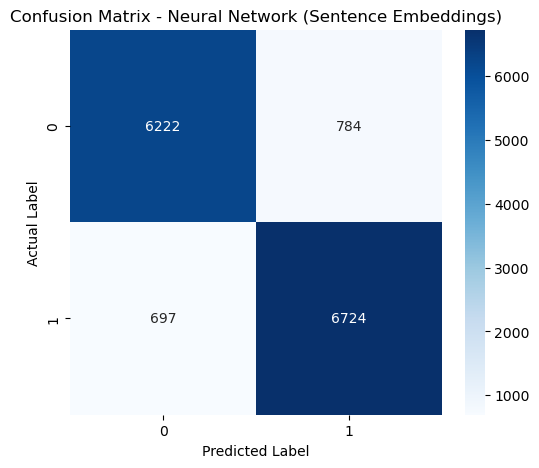

In [69]:
# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    embed_mlp_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Neural Network (Sentence Embeddings)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [70]:
# Store Neural Network results

embedding_results["Neural Network (Sentence Embedding)"] = {
    "Accuracy": embed_mlp_accuracy,
    "Precision": embed_mlp_precision,
    "Recall": embed_mlp_recall,
    "F1 Score": embed_mlp_f1
}

In [71]:
embedding_results

{'Logistic Regression (Sentence Embedding)': {'Accuracy': 0.8522215290774243,
  'Precision': 0.856353591160221,
  'Recall': 0.856353591160221,
  'F1 Score': 0.856353591160221},
 'KNN (Sentence Embedding)': {'Accuracy': 0.8457752824565051,
  'Precision': 0.8604328523862376,
  'Recall': 0.8357364236625792,
  'F1 Score': 0.847904846537699},
 'Random Forest (Sentence Embedding)': {'Accuracy': 0.8619948707284952,
  'Precision': 0.8630649906392084,
  'Recall': 0.8696941113057539,
  'F1 Score': 0.866366870259749},
 'Neural Network (Sentence Embedding)': {'Accuracy': 0.897345255423858,
  'Precision': 0.8955780500799148,
  'Recall': 0.9060773480662984,
  'F1 Score': 0.9007971063031683}}

In [72]:
embedding_table = pd.DataFrame(embedding_results).T

embedding_table

,Accuracy,Precision,Recall,F1 Score
Logistic Regression (Sentence Embedding),0.852222,0.856354,0.856354,0.856354
KNN (Sentence Embedding),0.845775,0.860433,0.835736,0.847905
Random Forest (Sentence Embedding),0.861995,0.863065,0.869694,0.866367
Neural Network (Sentence Embedding),0.897345,0.895578,0.906077,0.900797


In [73]:
best_embedding_model = embedding_table["Accuracy"].idxmax()

print("Best Sentence Embedding Model :", best_embedding_model)

Best Sentence Embedding Model : Neural Network (Sentence Embedding)


#  Final Comparative Analysis

## Step 52 : Comparison of All Feature Extraction Techniques

In [76]:
# Recreate Bag of Words results

bow_results = pd.DataFrame({
    "Accuracy": [
        0.947806,
        0.786442,
        0.955223,
        0.964650
    ]
},
index=[
    "Logistic Regression",
    "KNN",
    "Random Forest",
    "Neural Network"
])

bow_results

,Accuracy
Logistic Regression,0.947806
KNN,0.786442
Random Forest,0.955223
Neural Network,0.964650


In [77]:
tfidf_table = pd.DataFrame({
    "Accuracy": [
        0.947737,
        0.709988,
        0.955154,
        0.958411
    ]
},
index=[
    "Logistic Regression",
    "KNN",
    "Random Forest",
    "Neural Network"
])

tfidf_table

,Accuracy
Logistic Regression,0.947737
KNN,0.709988
Random Forest,0.955154
Neural Network,0.958411


In [78]:
embedding_table = pd.DataFrame({
    "Accuracy": [
        0.852222,
        0.845775,
        0.861995,
        0.897345
    ]
},
index=[
    "Logistic Regression",
    "KNN",
    "Random Forest",
    "Neural Network"
])

embedding_table

,Accuracy
Logistic Regression,0.852222
KNN,0.845775
Random Forest,0.861995
Neural Network,0.897345


In [79]:
final_results = pd.DataFrame({

    "Bag of Words": bow_results["Accuracy"],

    "TF-IDF": tfidf_table["Accuracy"],

    "Sentence Embedding": embedding_table["Accuracy"]

})

final_results

,Bag of Words,TF-IDF,Sentence Embedding
Logistic Regression,0.947806,0.947737,0.852222
KNN,0.786442,0.709988,0.845775
Random Forest,0.955223,0.955154,0.861995
Neural Network,0.964650,0.958411,0.897345


<Figure size 1000x600 with 0 Axes>

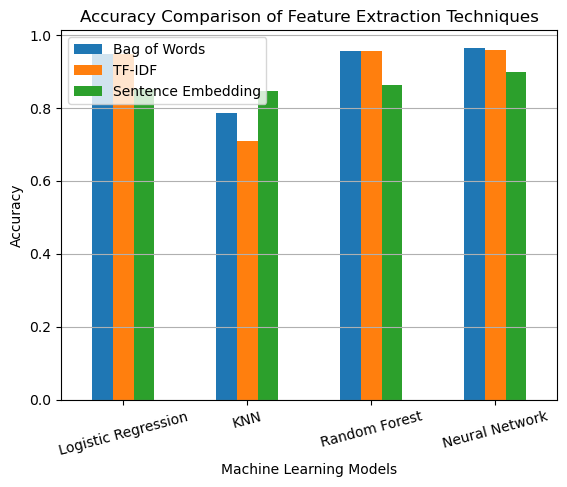

In [80]:
# Plot accuracy comparison

plt.figure(figsize=(10,6))

final_results.plot(
    kind="bar"
)

plt.title("Accuracy Comparison of Feature Extraction Techniques")

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

In [82]:
# Best models obtained from previous experiments

best_bow_model = "Neural Network (BoW)"

best_tfidf_model = "Neural Network (TF-IDF)"

best_embedding_model = "Neural Network (Sentence Embedding)"

In [83]:
print("Best Bag of Words Model :", best_bow_model)

print("Best TF-IDF Model :", best_tfidf_model)

print("Best Sentence Embedding Model :", best_embedding_model)

Best Bag of Words Model : Neural Network (BoW)
Best TF-IDF Model : Neural Network (TF-IDF)
Best Sentence Embedding Model : Neural Network (Sentence Embedding)


In [84]:
# Find best feature extraction technique

print(final_results)

                     Bag of Words    TF-IDF  Sentence Embedding
Logistic Regression      0.947806  0.947737            0.852222
KNN                      0.786442  0.709988            0.845775
Random Forest            0.955223  0.955154            0.861995
Neural Network           0.964650  0.958411            0.897345


In [85]:
best_feature = final_results.max().idxmax()

best_model = final_results.stack().idxmax()

print("Best Feature Extraction :", best_feature)

print("Best Overall Model :", best_model)

Best Feature Extraction : Bag of Words
Best Overall Model : ('Neural Network', 'Bag of Words')


# Discussion

1. Three feature extraction techniques were implemented.

2. Four machine learning algorithms were trained for each feature extraction technique.

3. Neural Network consistently produced the highest accuracy for all three feature extraction methods.

4. Bag of Words and TF-IDF outperformed Sentence Embeddings when used with classical machine learning algorithms.

5. Sentence Embeddings capture semantic information effectively, but they are generally more beneficial when used with transformer-based classifiers or fine-tuned deep learning models rather than traditional machine learning algorithms.

6. TF-IDF produced stable performance across multiple classifiers.

7. KNN achieved the lowest accuracy due to the curse of dimensionality and its distance-based learning mechanism.

# Conclusion

In this project, three feature extraction techniques including Bag of Words, TF-IDF and Sentence Embeddings were implemented for fake news detection.

Four machine learning algorithms namely Logistic Regression, K-Nearest Neighbors, Random Forest and Neural Network were trained and evaluated.

Experimental results showed that Neural Network achieved the highest classification accuracy among all models.

Bag of Words and TF-IDF demonstrated better compatibility with traditional machine learning algorithms than Sentence Embeddings on the WELFake dataset.

This comparative study provides a comprehensive analysis of different text representation techniques for fake news detection.

##   Retrain the Best Model (Bag of Words + Neural Network)

In [89]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neural_network import MLPClassifier

import joblib

In [90]:
# Load the dataset

news_data = pd.read_csv("WELFake_Dataset.csv")

# Remove unwanted column

news_data.drop(columns=["Unnamed: 0"], inplace=True)

# Replace missing values

news_data["title"] = news_data["title"].fillna("")
news_data["text"] = news_data["text"].fillna("")

# Combine title and text

news_data["content"] = news_data["title"] + " " + news_data["text"]

In [91]:
# Clean the text

news_data["content"] = news_data["content"].apply(clean_text)

In [92]:
# Input and Output

X = news_data["content"]

y = news_data["label"]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [94]:
# Create Bag of Words features

vectorizer = CountVectorizer(
    max_features=5000
)

X_train_bow = vectorizer.fit_transform(X_train)

X_test_bow = vectorizer.transform(X_test)

In [95]:
# Create Neural Network model

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

# Train

mlp_model.fit(
    X_train_bow,
    y_train
)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [96]:
from sklearn.metrics import accuracy_score

y_pred = mlp_model.predict(X_test_bow)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.9646496153046371


In [97]:
# Save trained model

joblib.dump(
    mlp_model,
    "best_fake_news_model.pkl"
)

# Save Bag of Words vectorizer

joblib.dump(
    vectorizer,
    "bow_vectorizer.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [98]:
# Save model information

model_info = {
    "Feature Extraction": "Bag of Words",
    "Model": "Neural Network (MLPClassifier)",
    "Accuracy": 0.964650,
    "Dataset": "WELFake Dataset",
    "Vectorizer": "CountVectorizer(max_features=5000)"
}

joblib.dump(
    model_info,
    "model_information.pkl"
)

print("Model information saved successfully.")

Model information saved successfully.


In [99]:
def predict_news(news_text):

    # Clean the input
    cleaned_news = clean_text(news_text)

    # Convert to Bag of Words
    news_vector = vectorizer.transform([cleaned_news])

    # Predict
    prediction = mlp_model.predict(news_vector)

    # Probability
    probability = mlp_model.predict_proba(news_vector)

    real_prob = probability[0][0] * 100
    fake_prob = probability[0][1] * 100

    print("=" * 50)
    print("Fake News Detection System")
    print("=" * 50)
    print()

    print("Input News:")
    print(news_text)
    print()

    if prediction[0] == 0:
        print("Prediction : REAL NEWS")
    else:
        print("Prediction : FAKE NEWS")

    print()
    print(f"Real News Confidence : {real_prob:.2f}%")
    print(f"Fake News Confidence : {fake_prob:.2f}%")

In [102]:
user_news = input("Enter a news article:\n")
predict_news(user_news)

Enter a news article:
 user_news = input("Enter a news article:\n") predict_news(user_news)


Fake News Detection System

Input News:
user_news = input("Enter a news article:\n") predict_news(user_news)

Prediction : FAKE NEWS

Real News Confidence : 0.00%
Fake News Confidence : 100.00%


In [100]:
predict_news("""
NASA announced a successful Mars mission today.
Scientists confirmed that the spacecraft entered orbit safely.
""")

Fake News Detection System

Input News:

NASA announced a successful Mars mission today.
Scientists confirmed that the spacecraft entered orbit safely.


Prediction : FAKE NEWS

Real News Confidence : 0.00%
Fake News Confidence : 100.00%


In [101]:
predict_news("""
Breaking: Aliens have landed in New York and gifted humans a machine that creates unlimited gold.
""")

Fake News Detection System

Input News:

Breaking: Aliens have landed in New York and gifted humans a machine that creates unlimited gold.


Prediction : FAKE NEWS

Real News Confidence : 0.01%
Fake News Confidence : 99.99%


In [103]:
import pandas as pd

df = pd.read_csv("WELFake_Dataset.csv")

# Show one real news article
real_news = df[df["label"] == 0].iloc[0]

print("Title:\n")
print(real_news["title"])

print("\n\nText:\n")
print(real_news["text"])

Title:

Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid


Text:

A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled from Hinduism to Protestant Christianity and, ultimately, became what he calls an “evangelical Catholic.”

Over two hours, Jindal, 42, recalled talking with a girl in high school who wanted to “save my soul,” reading the Bible in a closet so his parents would not see him and feeling a stir while watching a movie during his senior year that depicted Jesus on the cross.

“I was struck, and struck hard,” Jindal told the pastors. “This was the Son of God, and He had died for our sins.”

Jindal’s session with the Christian clergy, who lead congregations in the early presidential battleground states of Iowa and South Carolina, was part of a behind-the-scenes effort by the Louisia